# Анализ веб-логов интернет-магазина

Исходные данные: сведения о логах онлайн-магазина (3,5 ГБ)

Цели проекта:

* Реализовать парсинг сырых логов в структурированный DataFrame
* Очистить данные от пропусков и выбросов
* Провести анализ трафика и поведения пользователей

## Загрузка и предобработка данных

In [146]:
import pyspark.sql
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql.functions import *
from pyspark.sql.window import Window

colors = sns.color_palette('Paired')

### Загрузка данных

Выгрузим данные из zip папки в PySpark DataFrame

In [91]:
!unzip "/content/drive/MyDrive/access.log.zip" -d "/content/logs"

Archive:  /content/drive/MyDrive/access.log.zip
  inflating: /content/logs/access.log  


In [92]:
spark = pyspark.sql.SparkSession.builder.master("local[*]").getOrCreate()
data = spark.read.text('/content/logs/access.log')

Посмотрим, сколько записей в нашем файле

In [93]:
print(data.count())

10365152


### Парсинг данных

In [94]:
data.columns

['value']

Сейчас есть лишь один столбец со строками логов. Выделим из строк необходимые данные с помощью регулярного выражения.

In [95]:
log_pattern = r'(\S+) - - \[(.*?)\] \"(\S+) (\S+) \S+\" (\d{3}) (\d+|-) \"[^"]+\" \"([^"]+)\"'
data_parsed = data.select(
    regexp_extract('value', log_pattern, 1).alias('ip'),
    regexp_extract('value', log_pattern, 2).alias('datetime'),
    regexp_extract('value', log_pattern, 3).alias('method'),
    regexp_extract('value', log_pattern, 4).alias('request'),
    regexp_extract('value', log_pattern, 5).alias('status_str'),
    regexp_extract('value', log_pattern, 6).alias('size_str'),
    regexp_extract('value', log_pattern, 7).alias('user_agent')
)

### Предобработка данных

#### Обработка пропусков

Преобразуем значения, представленные пустой строкой или прочерком, в null для корректной обработки пропусков.

In [96]:
data_parsed = data_parsed.withColumn('status',
    when(col('status_str') == '', None)
    .when(col('status_str') == '-', None)
    .otherwise(col('status_str').cast('int'))
).withColumn('size',
    when(col('size_str') == '', None)
    .when(col('size_str') == '-', None)
    .otherwise(col('size_str').cast('int'))
).drop('status_str', 'size_str')

In [97]:
for c in data_parsed.columns:
  data_parsed = data_parsed.na.replace(['', '-'], None, c)

Теперь посчитаем количество пропусков в каждом столбце

In [98]:
data_parsed.cache()
data_parsed.count()

10365152

In [99]:
null_counts = data_parsed.select([
    sum(isnull(col(c)).cast("int")).alias(c)
    for c in data_parsed.columns
])

null_counts.show()

+---+--------+------+-------+----------+------+----+
| ip|datetime|method|request|user_agent|status|size|
+---+--------+------+-------+----------+------+----+
|315|     315|   315|    315|     14716|   315| 315|
+---+--------+------+-------+----------+------+----+



* Видим, что есть записи, где все значения пустые. Их можно удалить, так как таких записей очень мало.
* Также заметим, что около 0.1% данных имеют пропуск в агенте пользователя, так как доля от всех записей мала, удалим эти записи.

In [100]:
data_clean = data_parsed.dropna(how="any", subset=["user_agent"])
data_clean.show(5, truncate=False)

+-------------+--------------------------+------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------+----------------------------------------------------------------------------------------------------------------------------------------------+------+-----+
|ip           |datetime                  |method|request                                                                                                                                                               |user_agent                                                                                                                                    |status|size |
+-------------+--------------------------+------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------+--------------------------------------

In [101]:
null_counts_clean = data_clean.select([
    sum(isnull(col(c)).cast("int")).alias(c)
    for c in data_clean.columns
])

null_counts_clean.show()

+---+--------+------+-------+----------+------+----+
| ip|datetime|method|request|user_agent|status|size|
+---+--------+------+-------+----------+------+----+
|  0|       0|     0|      0|         0|     0|   0|
+---+--------+------+-------+----------+------+----+



#### Преобразование типов

Преобразуем тип столбца timestamp в datetime для более удобной работы с датами и временем. Создадим новые столбцы с характеристиками времени.

In [102]:
df = data_clean.withColumn('timestamp',
    to_timestamp(col('datetime'), 'dd/MMM/yyyy:HH:mm:ss Z')
)

df = df.withColumn('hour', hour('timestamp')) \
.withColumn('day', dayofmonth('timestamp')) \
.withColumn('month', month('timestamp')) \
.withColumn('year', year('timestamp')) \
.withColumn('weekday', dayofweek('timestamp')) \
.withColumn('date', date_format('timestamp', 'dd.MM.yyyy')) \
.withColumn('month_day', date_format('timestamp', 'MM-dd'))

In [103]:
total_count = df.count()

## Анализ данных

### Боты

Разделим трафик на созданный ботами (по ключевым словам в агенте) и пользователей. Рассмотрим процентное соотношение этих категорий.

In [104]:
df = df.withColumn('is_bot', col('user_agent').rlike('(?i)bot|spider|crawler'))
bot_stat = df.groupBy('is_bot').count()
bots_stat_percent = bot_stat.withColumn('percent', (col('count') / total_count * 100))
bots_stat_percent.show()

+------+-------+-----------------+
|is_bot|  count|          percent|
+------+-------+-----------------+
|  true|1115954|10.78171006516054|
| false|9234482|89.21828993483946|
+------+-------+-----------------+



In [105]:
unique_bots_stat = df.groupBy('is_bot').agg(count_distinct('ip').alias('unique_ip'))
total_unique_ips = df.select(count_distinct('ip')).collect()[0][0]
unique_bots_stat_percent = unique_bots_stat.withColumn('percent', (col('unique_ip') / total_unique_ips * 100))
unique_bots_stat_percent.show()

+------+---------+------------------+
|is_bot|unique_ip|           percent|
+------+---------+------------------+
|  true|     1463|0.5662663193463359|
| false|   256941| 99.45115130496713|
+------+---------+------------------+



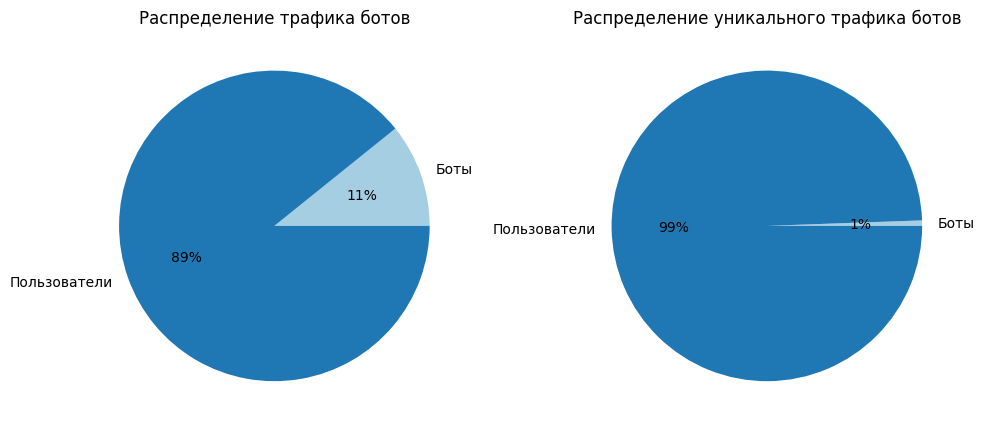

In [147]:
bots_stat_percent_pd = bots_stat_percent.toPandas()
unique_bots_stat_percent_pd = unique_bots_stat_percent.toPandas()

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.pie(bots_stat_percent_pd['percent'], labels=['Боты', 'Пользователи'], autopct='%1.0f%%', colors=colors)
plt.title('Распределение трафика ботов')

plt.subplot(1, 2, 2)
plt.pie(unique_bots_stat_percent_pd['percent'], labels=['Боты', 'Пользователи'], autopct='%1.0f%%', colors=colors)
plt.title('Распределение уникального трафика ботов')

plt.tight_layout()
plt.show()

Видим, что доля пользовательского трафика намного больше доли трафика, созданного ботами. Также по распредлению уникального можно заметить, что боты отправлют много запросов с одних и тех же адресов.

Найдём IP-адреса ботов с наибольшим количеством отправленных запросов.

In [107]:
bots = df.filter(col('is_bot') == True)
bots_count = bots.count()
bots = bots.withColumn('bot_name',
    when(col('user_agent').rlike('(?i)googlebot'), 'Googlebot')
    .when(col('user_agent').rlike('(?i)bingbot'), 'Bingbot')
    .when(col('user_agent').rlike('(?i)yandexbot'), 'Yandexbot')
    .when(col('user_agent').rlike('(?i)ahrefsbot'), 'AhrefsBot')
    .when(col('user_agent').rlike('(?i)facebookexternalhit'), 'FacebookBot')
    .when(col('user_agent').rlike('(?i)baiduspider'), 'BaiduSpider')
    .when(col('user_agent').rlike('(?i)gptbot'), 'GPTBot')
    .when(col('user_agent').rlike('(?i)awariorssbot'), 'AwarioRssBot')
    .otherwise('Other')
)

In [108]:
bots_stat_with_names_by_ip = bots.groupBy('ip').agg(
    count('*').alias('req_count'),
    first('user_agent').alias('bot_name')
).orderBy(desc('req_count')).limit(10).withColumn('percent', col('req_count') / bots_count * 100)

bots_stat_with_names_by_ip.show(truncate=False)

+-------------+---------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------+------------------+
|ip           |req_count|bot_name                                                                                                                                                              |percent           |
+-------------+---------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------+------------------+
|66.249.66.194|353288   |Mozilla/5.0 (compatible; Googlebot/2.1; +http://www.google.com/bot.html)                                                                                              |31.65793572136486 |
|66.249.66.91 |314348   |Mozilla/5.0 (compatible; Googlebot/2.1; +http://www.google.com/bot.html)                                                       

Видно, что наибольшее число запросов отправляет GoogleBot с нескольких IP-адресов, далее идёт AppleBot и bingbot.

Посмотрим, какой процент от трафика ботов приходится на каждый бот

In [109]:
bots_stat_with_names = bots.groupBy('bot_name').agg(
    count('*').alias('req_count'),
    first('user_agent').alias('bot_name')
).orderBy(desc('req_count')).withColumn('percent', col('req_count') / bots_count * 100)

bots_stat_with_names.show(truncate=False)

+------------+---------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------+---------------------+
|bot_name    |req_count|bot_name                                                                                                                                                              |percent              |
+------------+---------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------+---------------------+
|Googlebot   |801797   |Mozilla/5.0 (compatible; Googlebot/2.1; +http://www.google.com/bot.html)                                                                                              |71.84857081922732    |
|Bingbot     |200700   |Mozilla/5.0 (compatible; bingbot/2.0; +http://www.bing.com/bingbot.htm)                                                 

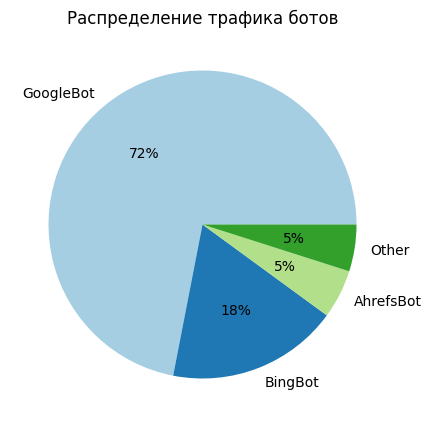

In [148]:
bots_stat_with_names_pd = bots_stat_with_names.limit(4).toPandas()
plt.figure(figsize=(5, 5))
plt.pie(bots_stat_with_names_pd['percent'], labels=['GoogleBot', 'BingBot', 'AhrefsBot', 'Other'], autopct='%1.0f%%', colors=colors)
plt.title('Распределение трафика ботов')
plt.show()

Большинство запросов отправляет GoogleBot (более 70%). На втором месте BingBot, на третьем - AhrefsBot.

### Ошибки

In [111]:
statuses = df.groupBy('status').count()
statuses_percent = statuses.withColumn('percent', col('count') / total_count * 100).orderBy(desc('percent'))
statuses_percent.show(10)

+------+-------+--------------------+
|status|  count|             percent|
+------+-------+--------------------+
|   200|9566056|   92.42176851293993|
|   304| 340226|  3.2870692596910898|
|   302| 199815|  1.9304983867346266|
|   404| 104993|  1.0143823893022477|
|   301|  67183|  0.6490837680654226|
|   499|  50850|  0.4912836522055689|
|   500|  14266|  0.1378299426227069|
|   403|   5632| 0.05441316674969054|
|   502|    798|0.007709820146706864|
|   401|    323|0.003120641487952778|
+------+-------+--------------------+
only showing top 10 rows


Видим, что большинство запросов успешно выполняются (92% запросов со статусом 200). Часть запросов перенаправляются (статусы 304, 302 и 301). Около 1% запросов получают в ответ статус ошибки не найденной страницы (404).

Распределим запросы по часто встречающимся типам

In [112]:
df = df.withColumn('request_type',
    when(col('request').contains('/product/'), 'product')
    .when(col('request').contains('/image/'), 'image')
    .when(col('request').contains('/filter/'), 'filter')
    .when(col('request').contains('/settings/'), 'settings')
    .when(col('request').contains('/article/'), 'article')
    .when(col('request').contains('/static/'), 'static')
    .when(col('request').contains('preconnect'), 'preconnect')
    .when(col('request').contains('/browse'), 'browse')
    .when(col('request').contains('icon'), 'icon')
    .otherwise('other')
)

Рассмотрим распределение запросов, вызвавших ошибку 404, по типам их URL

In [113]:
error = df.filter(col('status') == 404)
error_count = error.count()
print(error_count)
error_stat = error.groupBy('request_type').count()
error_stat = error_stat.withColumn('percent', col('count') / error_count * 100).orderBy(desc('percent'))
error_stat.show(10)

104993
+------------+-----+--------------------+
|request_type|count|             percent|
+------------+-----+--------------------+
|        icon|62620|   59.64207137618699|
|  preconnect|21230|   20.22039564542398|
|     product|11741|   11.18265027192289|
|       other| 6288|  5.9889706932843145|
|      browse| 2295|   2.185860009714933|
|      static|  664|  0.6324231139218806|
|      filter|  108| 0.10286400045717334|
|     article|   36| 0.03428800015239111|
|    settings|   10| 0.00952444448677531|
|       image|    1|9.524444486775309E-4|
+------------+-----+--------------------+



По распределению видим, что чаще всего запрос по не существующему адресу происходит при попытке получить файл иконки. Доля попыток перехода на страницу не существующего товара среди запросов, вызвавших ошибку 404, составляет 11%.

In [114]:
error = df.filter(col('status') == 404)
error_stat = error.groupBy('request').count().orderBy(desc('count'))
error_stat.show(10, truncate=False)

+-------------------------------------------------------------+-----+
|request                                                      |count|
+-------------------------------------------------------------+-----+
|/apple-touch-icon-precomposed.png                            |17836|
|/apple-touch-icon.png                                        |16786|
|/apple-touch-icon-120x120-precomposed.png                    |13217|
|/apple-touch-icon-120x120.png                                |13217|
|/product/themes/default-rtl/style.css                        |959  |
|/product/falsedefault-rtl/style.css                          |821  |
|/apple-touch-icon-152x152.png                                |763  |
|/apple-touch-icon-152x152-precomposed.png                    |760  |
|/m/alexaGooleAnalitic                                        |660  |
|/static/plugins/ckeditor-3.6.2.2/js/ckeditor/contents.min.css|271  |
+-------------------------------------------------------------+-----+
only showing top 10 

Видно, что чаще всего ошибка 404 возникает при попытке получить статичные файлы (иконки и стили)

### Поведение пользователей

По URL запросов найдём самые просматриваемые товары

In [132]:
products = df.filter(col('request').contains('/product/'))
products = products.withColumn('product_id', regexp_extract('request', r'/product/(\d+)', 1))
products = products.filter(col('product_id') != '')
products_count = products.count()
products_stat = products.groupBy('product_id').count().orderBy(desc('count')).limit(10)
products_stat = products_stat.withColumn('product_percent', col('count') / products_count * 100)
products_stat.show()

+----------+-----+-------------------+
|product_id|count|    product_percent|
+----------+-----+-------------------+
|        50|30994|  8.166287256017874|
|     33953| 1538|  0.405231651279457|
|     33968| 1399| 0.3686079844863201|
|     34286| 1371| 0.3612305552042494|
|     33956| 1284|0.33830782850638674|
|     33960| 1257|0.33119387884153284|
|     33954| 1243|0.32750516420049747|
|     31720| 1166| 0.3072172336748029|
|     33722|  939|0.24740736056658658|
|     33952|  929|0.24477256439441844|
+----------+-----+-------------------+



Видим аномалию: товар с ID=50 (сам ID заметно отличается от остальных) имеет очень высокую долю просмотров (8%) в отличие от остальных товаров (второе место - 0.4%). Посмотрим как выглядит адрес товаров с ID=50, возможно, допущена ошибка в выделение идентификатора.

In [134]:
products.filter(col('product_id') == '50').show(10, truncate=False)

+-------------+--------------------------+------+--------------------------+--------------------------------------------------------------------------------------------------------------------------------------------------------+------+----+-------------------+----+---+-----+----+-------+----------+---------+------+------------+----------+
|ip           |datetime                  |method|request                   |user_agent                                                                                                                                              |status|size|timestamp          |hour|day|month|year|weekday|date      |month_day|is_bot|request_type|product_id|
+-------------+--------------------------+------+--------------------------+--------------------------------------------------------------------------------------------------------------------------------------------------------+------+----+-------------------+----+---+-----+----+-------+----------+---------+------

Видим, что и правда выделение идентификатора происходит неправильно и засчитываются запросы на загрузку картинки, где 50 является размером изображения. Исправим выделение идентификатора товара из адреса запроса.

In [129]:
products = df.filter(col('request').startswith('/product/'))
products = products.withColumn('product_id', regexp_extract('request', r'^/product/(\d+)', 1))
products = products.filter(col('product_id') != '')
products_count = products.count()
products_stat = products.groupBy('product_id').count().orderBy(desc('count')).limit(10)
products_stat = products_stat.withColumn('product_percent', col('count') / products_count * 100)
products_stat.show()

+----------+-----+-------------------+
|product_id|count|    product_percent|
+----------+-----+-------------------+
|     33953|  762| 0.3432370587917335|
|     34286|  738|  0.332426442766797|
|     33968|  692|0.31170609538566874|
|     33954|  686|0.30900344137943464|
|     33956|  593| 0.2671123042828057|
|     33960|  533|0.24008576422046451|
|     33952|  517| 0.2328786868705068|
|     31720|  483| 0.2175636475018468|
|     33722|  347|0.15630349002720673|
|     33626|  323|0.14549287400227023|
+----------+-----+-------------------+



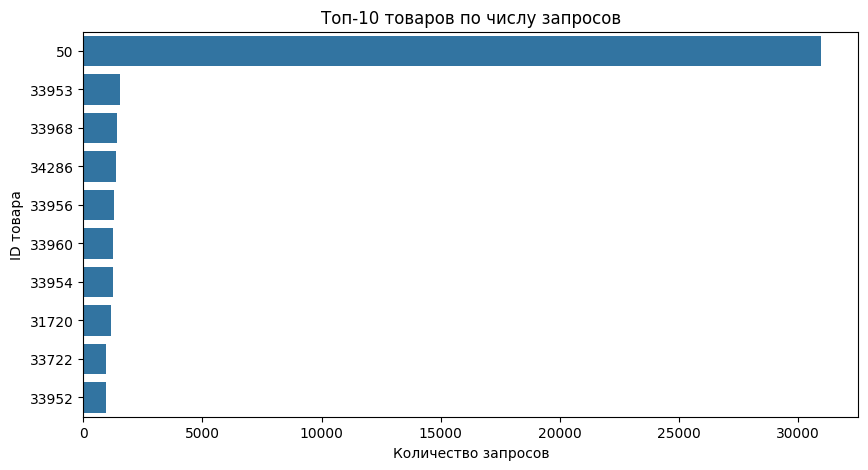

In [149]:
products_stat_pd = products_stat.toPandas()

plt.figure(figsize=(10, 5))
sns.barplot(data=products_stat_pd, y='product_id', x='count', color=colors[1])
plt.title('Топ-10 товаров по числу запросов')
plt.xlabel('Количество запросов')
plt.ylabel('ID товара')
plt.show()

После исправления видим, что рапределение спроса на товары равномерно. Для топ 10 товаров количество запросов на их просмотр составляет 0.15-0.34% от продуктовых запросов.

С помощью оконной функции определим количество сессий и их продолжительность для каждого пользователя

In [117]:
window_ip = Window.partitionBy('ip').orderBy('timestamp')

users = df.filter(col('is_bot') == False)
users_sessioned = users.withColumn('prev_time', lag('timestamp').over(window_ip))
users_sessioned = users_sessioned.withColumn('time_diff',
                                       when(col('prev_time').isNull(), None)
                                       .otherwise((unix_timestamp('timestamp') - unix_timestamp('prev_time')) / 60))
users_sessioned = users_sessioned.withColumn('is_new_session',
                                       when(col('time_diff') > 30, 1).otherwise(0))
users_sessioned = users_sessioned.withColumn('session_id', sum('is_new_session').over(window_ip))\
.withColumn('global_session_id', concat(col('ip'), lit('_'), col('session_id')))
users_sessioned.cache()
users_sessioned.show(5)

+------------+--------------------+------+--------------------+--------------------+------+-----+-------------------+----+---+-----+----+-------+----------+---------+------+------------+-------------------+--------------------+--------------+----------+-----------------+
|          ip|            datetime|method|             request|          user_agent|status| size|          timestamp|hour|day|month|year|weekday|      date|month_day|is_bot|request_type|          prev_time|           time_diff|is_new_session|session_id|global_session_id|
+------------+--------------------+------+--------------------+--------------------+------+-----+-------------------+----+---+-----+----+-------+----------+---------+------+------------+-------------------+--------------------+--------------+----------+-----------------+
|103.255.4.61|23/Jan/2019:08:55...|   GET|/image/34039?name...|Mozilla/5.0 (Wind...|   200| 4088|2019-01-23 05:25:09|   5| 23|    1|2019|      4|23.01.2019|    01-23| false|       imag

Вычислим продолжительность каждой сессии

In [118]:
session_stat = users_sessioned.groupBy(['ip', 'session_id']).agg(
    count('*').alias('request_cnt'),
    min('timestamp').alias('session_start'),
    max('timestamp').alias('session_end')
).withColumn('session_duration', (unix_timestamp('session_end') - unix_timestamp('session_start')) / 60) \
.withColumn('date', date_format('session_start', 'dd.MM.yyyy'))
session_stat.orderBy(desc('request_cnt')).show(5)

+---------------+----------+-----------+-------------------+-------------------+-----------------+----------+
|             ip|session_id|request_cnt|      session_start|        session_end| session_duration|      date|
+---------------+----------+-----------+-------------------+-------------------+-----------------+----------+
|  104.222.32.91|         4|      42053|2019-01-26 05:52:12|2019-01-26 16:25:59|633.7833333333333|26.01.2019|
|    91.99.72.15|         0|      38694|2019-01-22 00:26:17|2019-01-26 16:58:26|          6752.15|22.01.2019|
|    91.99.47.57|         1|      38255|2019-01-26 04:16:24|2019-01-26 15:52:08|695.7333333333333|26.01.2019|
|    91.99.30.32|         0|      27756|2019-01-22 04:33:55|2019-01-22 16:00:22|           686.45|22.01.2019|
|151.239.241.163|         0|      26676|2019-01-22 04:32:28|2019-01-22 17:27:10|            774.7|22.01.2019|
+---------------+----------+-----------+-------------------+-------------------+-----------------+----------+
only showi

Найдём среднюю продолжительность сессий за отдельные дни

In [119]:
session_stat_by_date = session_stat.groupBy('date').avg('session_duration').orderBy('date')
session_stat_by_date.show(5)

+----------+---------------------+
|      date|avg(session_duration)|
+----------+---------------------+
|22.01.2019|   3.3677992606644302|
|23.01.2019|   2.9372670886983614|
|24.01.2019|     2.66860422831296|
|25.01.2019|    2.743301376013525|
|26.01.2019|   3.1056380458166166|
+----------+---------------------+



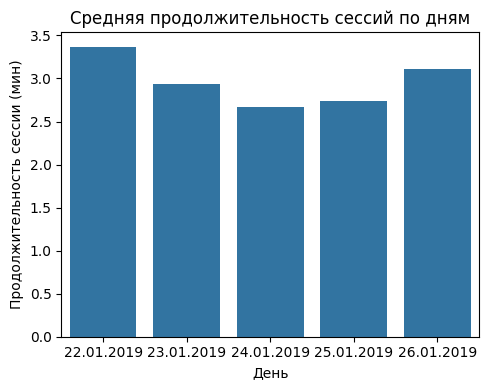

In [150]:
session_stat_by_date_pd = session_stat_by_date.toPandas()

plt.figure(figsize=(5, 4))
sns.barplot(data=session_stat_by_date_pd, x='date', y='avg(session_duration)', color=colors[1])
plt.title('Средняя продолжительность сессий по дням')
plt.ylabel('Продолжительность сессии (мин)')
plt.xlabel('День')
plt.tight_layout()
plt.show()

Видим, что средняя продолжительность сессии составляет около 3 минут

Рассмотрим распределение количества сессий по датам, дням недели и часам.

Заметим, что в последний день (26.01.2019) нет данных по всем часам (только до 17), поэтому не будем использовать данные по этому дню в дальнейшем анализе.

In [121]:
users_sessioned = users_sessioned.filter(col('date') != '26.01.2019')
session_by_date = users_sessioned.groupby('date')\
.agg(count_distinct('global_session_id').alias('session_cnt')).orderBy('date')
session_by_date.cache()
session_by_date.show()
session_by_weekday = users_sessioned.groupby('weekday')\
.agg(count_distinct('global_session_id').alias('session_cnt')).orderBy('weekday')
session_by_weekday.cache()
session_by_weekday.show()
session_by_hour = users_sessioned.groupby('hour')\
.agg(count_distinct('global_session_id').alias('session_cnt')).orderBy('hour')
session_by_hour.cache()
session_by_hour.show()

+----------+-----------+
|      date|session_cnt|
+----------+-----------+
|22.01.2019|      68530|
|23.01.2019|      65106|
|24.01.2019|      66936|
|25.01.2019|      63148|
+----------+-----------+

+-------+-----------+
|weekday|session_cnt|
+-------+-----------+
|      3|      68530|
|      4|      65106|
|      5|      66936|
|      6|      63148|
+-------+-----------+

+----+-----------+
|hour|session_cnt|
+----+-----------+
|   0|       1949|
|   1|       1675|
|   2|       1993|
|   3|       4079|
|   4|       7282|
|   5|      10117|
|   6|      12375|
|   7|      13871|
|   8|      14711|
|   9|      15055|
|  10|      15383|
|  11|      14990|
|  12|      13655|
|  13|      13462|
|  14|      13707|
|  15|      15448|
|  16|      15540|
|  17|      15577|
|  18|      17761|
|  19|      18210|
+----+-----------+
only showing top 20 rows


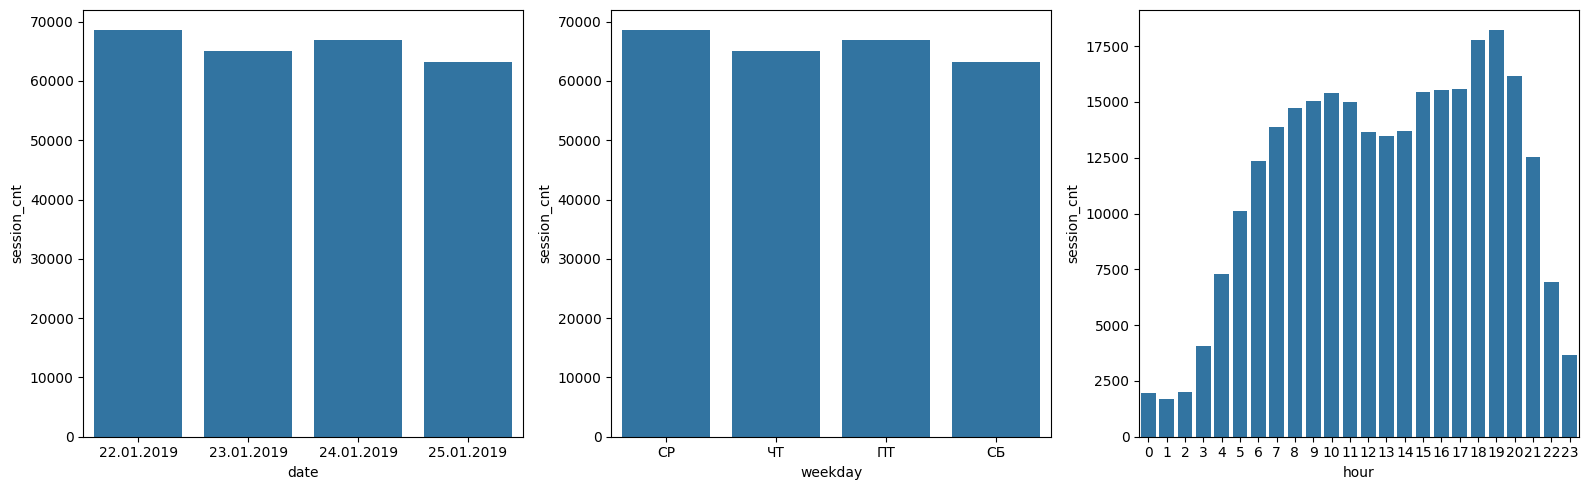

In [159]:
session_by_date_pd = session_by_date.toPandas()
session_by_weekday_pd = session_by_weekday.toPandas()
mapping = {3:'СР', 4:'ЧТ', 5:'ПТ', 6:'СБ', 7:'ВС'}
session_by_weekday_pd['weekday'] = session_by_weekday_pd['weekday'].map(mapping)
session_by_hour_pd = session_by_hour.toPandas()

plt.figure(figsize=(16, 5))
plt.subplot(1, 3, 1)
sns.barplot(data=session_by_date_pd, x='date', y='session_cnt', color=colors[1])
plt.subplot(1, 3, 2)
sns.barplot(data=session_by_weekday_pd, x='weekday', y='session_cnt', color=colors[1])
plt.subplot(1, 3, 3)
sns.barplot(data=session_by_hour_pd, x='hour', y='session_cnt', color=colors[1])
plt.tight_layout()
plt.show()

* В субботу объём трафика немного снижается
* По распределению трафика по часам видно, что наибольшее число сессий достигается в вечернее время, понижение - в дневное время и значительное уменьшение в ночные часы

## Выводы

* 10,8% трафика генерируются ботами, преимущественно GoogleBot (>70% бот-трафика), из чего следует, что необходима фильтрация для анализа поведения реальных пользователей
* Боты используют только 0.57% уникальных IP-адресов, что говорит об активном сканировании
* 92% запросов выполняется успшено (со статусом 200)
* Основная причина ошибок 404 (60%) - не удавшиеся попытки загрузки иконки ('/apple-touch-icon*.png')
* Пик активности достигается в вечерние часы (18-19)
* Самая низкая активность ночью
* Спрос на товары распределён равномерно, что говорит об отсутствие "бестселлера" среди товаров
* Средняя продолжительность сессии примерно 3 минуты
* Самые длинные сессии наблюдаются 22 января (среда)


*Рекомендации:*
* Добавить недостающие иконки для IOS-устройств для снижения нагрузки на сервера и улучшения пользовательского опыта
* Оптимизировать работу сервера во время пиковых вечерних нагрузок